# 01 - Exploratory Data Analysis
**Credit Score Classification | MLOps Group 8**

This notebook performs a thorough EDA on the raw training dataset:
- Dataset overview and shape
- Missing value analysis
- Target distribution
- Univariate distributions (numeric + categorical)
- Bivariate analysis by Credit_Score
- Correlation heatmap
- Key insights summary

In [18]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

REPO_ROOT   = Path().resolve().parent
DATA_RAW    = REPO_ROOT / 'data' / 'raw' / 'train_raw.csv'
FIGURES_DIR = REPO_ROOT / 'artifacts' / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Repo root:', REPO_ROOT)
print('Data path:', DATA_RAW)

Repo root: D:\DSEB\SEM 6\MLOps\MLOps-Group-8
Data path: D:\DSEB\SEM 6\MLOps\MLOps-Group-8\data\raw\train_raw.csv


## 1. Load Raw Data

In [19]:
df = pd.read_csv(DATA_RAW, low_memory=False)
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.000,_,809.98,26.823,22 Years and 1 Months,No,49.575,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.000,Good,809.98,31.945,NaN,No,49.575,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.000,Good,809.98,28.609,22 Years and 3 Months,No,49.575,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.000,Good,809.98,31.378,22 Years and 4 Months,No,49.575,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.000,Good,809.98,24.797,22 Years and 5 Months,No,49.575,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [20]:
print('=== dtypes ===')
print(df.dtypes)
print('\n=== memory usage ===')
print(df.memory_usage(deep=True).sum() / 1024**2, 'MB')

=== dtypes ===
ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score 

## 2. Missing Value Analysis

In [21]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = missing / len(df) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0]
print(f'Columns with missing values: {len(missing_df)}')
missing_df

Columns with missing values: 8


,missing_count,missing_pct
Monthly_Inhand_Salary,15002,15.002
Type_of_Loan,11408,11.408
Name,9985,9.985
Credit_History_Age,9030,9.030
Num_of_Delayed_Payment,7002,7.002
Amount_invested_monthly,4479,4.479
Num_Credit_Inquiries,1965,1.965
Monthly_Balance,1200,1.200


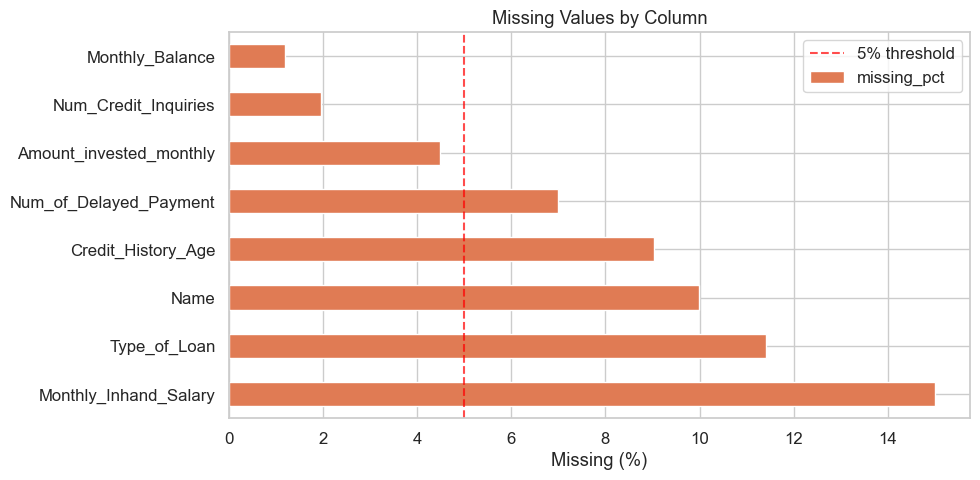

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_df['missing_pct'].plot(kind='barh', ax=ax, color='#e07b54')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column')
ax.axvline(5, color='red', ls='--', alpha=0.7, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'missing_values.png', dpi=150)
plt.show()

## 3. Target Distribution

In [23]:
target_counts = df['Credit_Score'].value_counts().sort_index()
target_pct    = target_counts / len(df) * 100
print('Credit_Score distribution:')
for cls, cnt, pct in zip(target_counts.index, target_counts.values, target_pct.values):
    print(f'  {cls:10s}: {cnt:7,d}  ({pct:.1f}%)')

Credit_Score distribution:
  Good      :  17,828  (17.8%)
  Poor      :  28,998  (29.0%)
  Standard  :  53,174  (53.2%)


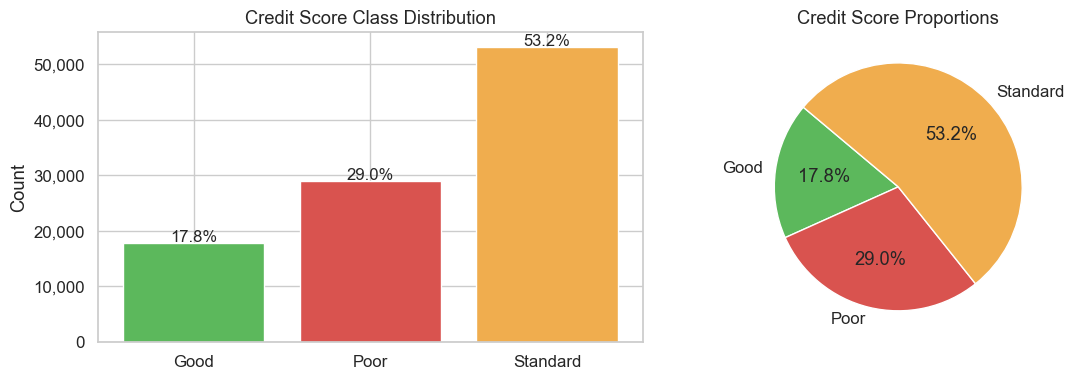

In [24]:
color_map = {'Poor': '#d9534f', 'Standard': '#f0ad4e', 'Good': '#5cb85c'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(target_counts.index,
                   target_counts.values,
                   color=[color_map.get(c, 'steelblue') for c in target_counts.index])
for bar, pct in zip(bars, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{pct:.1f}%', ha='center', fontsize=12)
axes[0].set_title('Credit Score Class Distribution')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie(target_counts.values,
            labels=target_counts.index,
            autopct='%1.1f%%',
            colors=[color_map.get(c, 'steelblue') for c in target_counts.index],
            startangle=140)
axes[1].set_title('Credit Score Proportions')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_distribution.png', dpi=150)
plt.show()

## 4. Numeric Feature Distributions

In [25]:
# Identify numeric columns (exclude ID/target)
EXCLUDE = ['ID', 'Customer_ID', 'Name', 'SSN', 'Month', 'Credit_Score']
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in EXCLUDE]
cat_cols = [c for c in df.select_dtypes(include=['object']).columns if c not in EXCLUDE]
print(f'Numeric cols ({len(num_cols)}):', num_cols)
print(f'Categorical cols ({len(cat_cols)}):', cat_cols)

Numeric cols (8): ['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month']
Categorical cols (14): ['Age', 'Occupation', 'Annual_Income', 'Num_of_Loan', 'Type_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance']


In [26]:
print(df[num_cols].describe().T.to_string())

                              count     mean      std     min      25%      50%      75%       max
Monthly_Inhand_Salary     84998.000 4194.171 3183.686 303.645 1625.568 3093.745 5957.448 15204.633
Num_Bank_Accounts        100000.000   17.091  117.405  -1.000    3.000    6.000    7.000  1798.000
Num_Credit_Card          100000.000   22.474  129.057   0.000    4.000    5.000    7.000  1499.000
Interest_Rate            100000.000   72.466  466.423   1.000    8.000   13.000   20.000  5797.000
Delay_from_due_date      100000.000   21.069   14.860  -5.000   10.000   18.000   28.000    67.000
Num_Credit_Inquiries      98035.000   27.754  193.177   0.000    3.000    6.000    9.000  2597.000
Credit_Utilization_Ratio 100000.000   32.285    5.117  20.000   28.053   32.306   36.497    50.000
Total_EMI_per_month      100000.000 1403.118 8306.041   0.000   30.307   69.249  161.224 82331.000


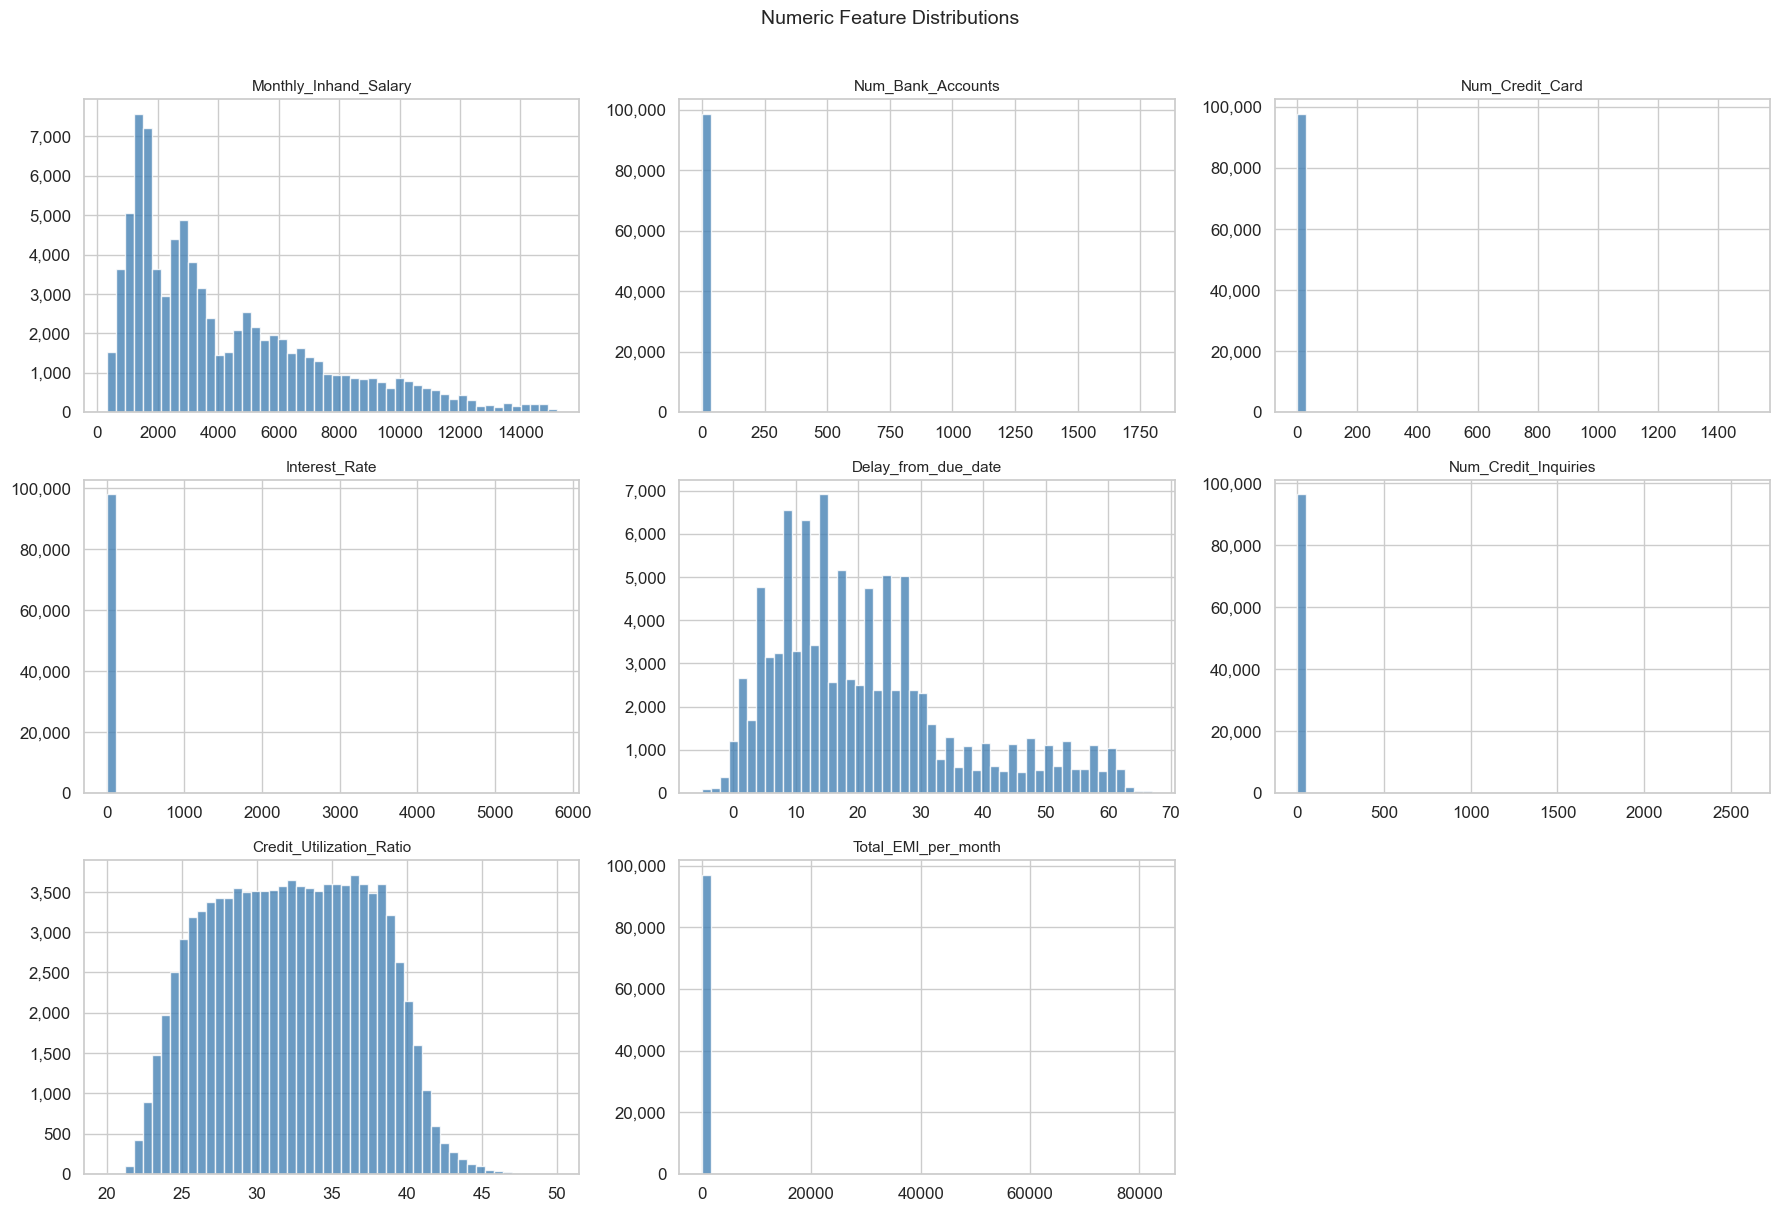

In [27]:
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Categorical Feature Distributions

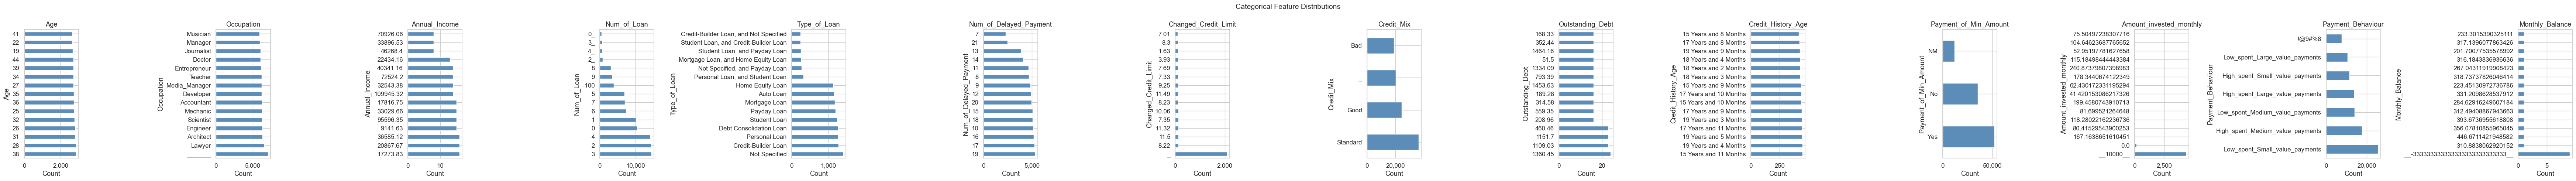

In [28]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 5))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts().head(15)
    vc.plot(kind='barh', ax=ax, color='#5b8db8')
    ax.set_title(col)
    ax.set_xlabel('Count')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Categorical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Bivariate Analysis: Feature vs. Credit_Score

In [ ]:
key_num_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
    'Outstanding_Debt', 'Credit_Utilization_Ratio',
    'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Credit_History_Age'
]
key_num_cols = [c for c in key_num_cols if c in df.columns]

# Coerce all key columns to numeric and parse Credit_History_Age string
import re as _re
plot_df = df.copy()
if 'Credit_History_Age' in plot_df.columns and plot_df['Credit_History_Age'].dtype == object:
    def _parse_cha(val):
        if pd.isna(val):
            return float('nan')
        m = _re.search(r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?', str(val))
        return int(m.group(1)) * 12 + int(m.group(2)) if m else float('nan')
    plot_df['Credit_History_Age'] = plot_df['Credit_History_Age'].apply(_parse_cha)
# Coerce remaining string columns to numeric
for _col in key_num_cols:
    if plot_df[_col].dtype == object:
        plot_df[_col] = pd.to_numeric(
            plot_df[_col].astype(str).str.replace(r'[^\d.]', '', regex=True),
            errors='coerce'
        )

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
order   = ['Poor', 'Standard', 'Good']
palette = {'Poor': '#d9534f', 'Standard': '#f0ad4e', 'Good': '#5cb85c'}

for i, col in enumerate(key_num_cols):
    ax = axes[i]
    sns.boxplot(
        data=plot_df[plot_df['Credit_Score'].isin(order)],
        x='Credit_Score', y=col, order=order,
        palette=palette, ax=ax, showfliers=False
    )
    ax.set_title(col.replace('_', ' '), fontsize=11)
    ax.set_xlabel('')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
    col_max = pd.to_numeric(plot_df[col], errors='coerce').dropna().max()
    if isinstance(col_max, (int, float)) and col_max > 9999:
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
        )
    ax.tick_params(axis='y', labelsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Key Numeric Features vs Credit Score', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'bivariate_numeric.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Credit_Mix vs Credit Score — stacked bar (garbage '_' filtered)
if 'Credit_Mix' in df.columns:
    cm_data = df[df['Credit_Mix'].notna() & (df['Credit_Mix'] != '_')]
    ct = pd.crosstab(cm_data['Credit_Mix'], cm_data['Credit_Score'],
                     normalize='index') * 100
    ct = ct.reindex(columns=['Poor', 'Standard', 'Good'], fill_value=0)
    row_order = [r for r in ['Bad', 'Standard', 'Good'] if r in ct.index]
    ct = ct.reindex(row_order)
    fig, ax = plt.subplots(figsize=(8, 5))
    ct.plot(kind='bar', stacked=True,
            color=['#d9534f', '#f0ad4e', '#5cb85c'], ax=ax)
    ax.set_title('Credit Mix vs Credit Score')
    ax.set_ylabel('Percentage (%)')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Credit Score')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'credit_mix_vs_score.png', dpi=150, bbox_inches='tight')
    plt.show()


## 7. Correlation Heatmap

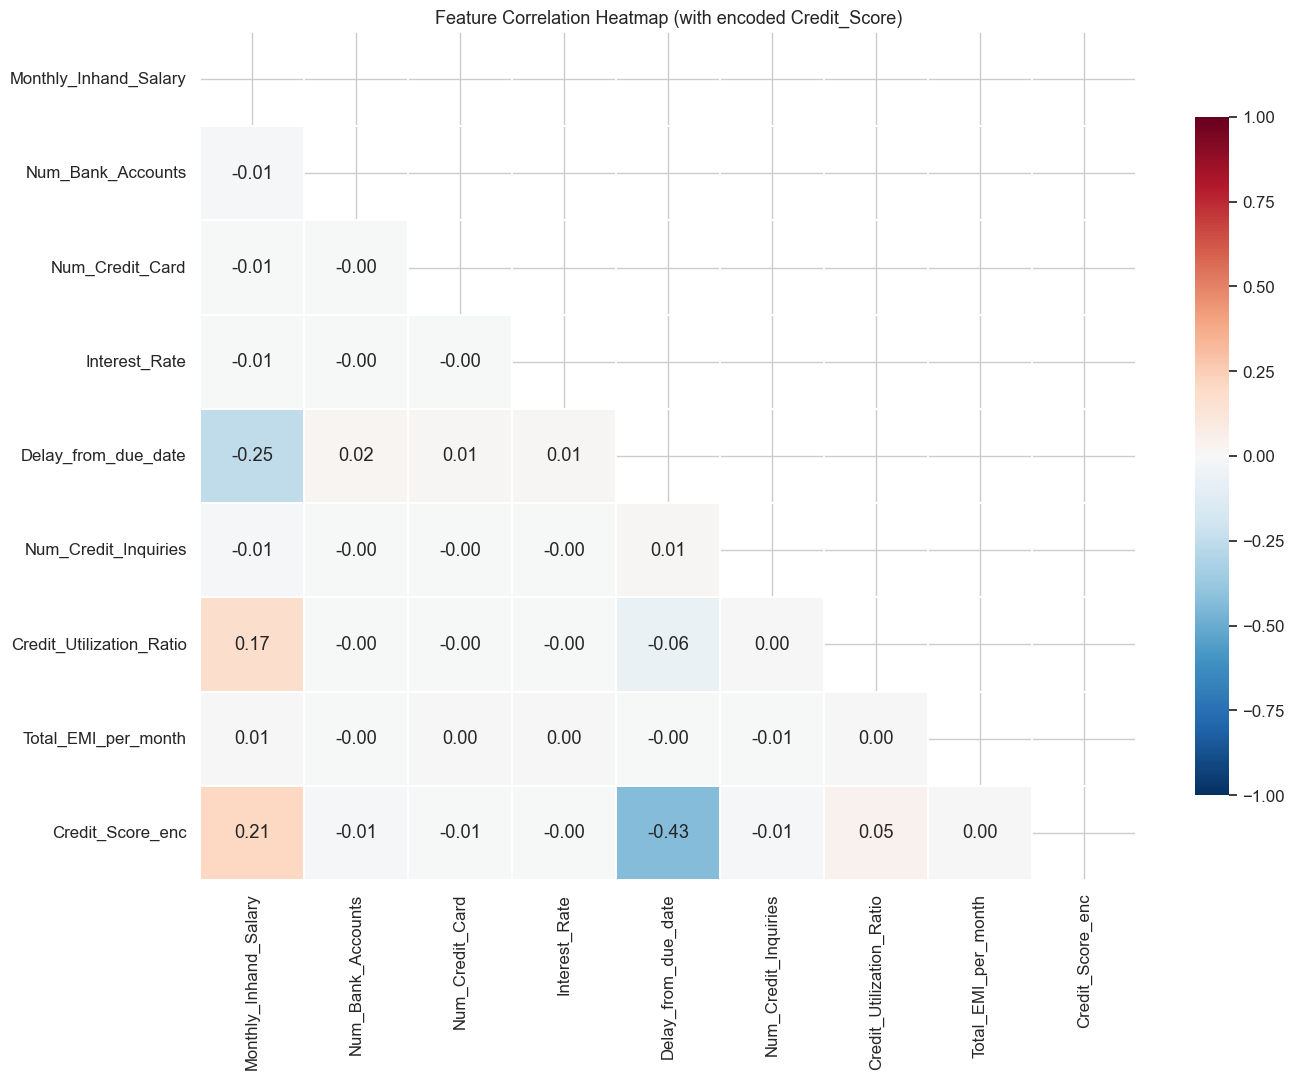

In [31]:
# Encode target for correlation
label_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
df_corr = df[num_cols + ['Credit_Score']].copy()
df_corr['Credit_Score_enc'] = df_corr['Credit_Score'].map(label_map)
df_corr = df_corr.drop(columns=['Credit_Score'])

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap (with encoded Credit_Score)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Top correlations with target
target_corr = corr_matrix['Credit_Score_enc'].drop('Credit_Score_enc').abs().sort_values(ascending=False)
print('Top correlations with Credit Score:')
print(target_corr.head(12).to_string())

Top correlations with Credit Score:
Delay_from_due_date        0.432
Monthly_Inhand_Salary      0.209
Credit_Utilization_Ratio   0.046
Num_Credit_Inquiries       0.011
Num_Bank_Accounts          0.010
Num_Credit_Card            0.008
Total_EMI_per_month        0.004
Interest_Rate              0.003


## 8. Outlier Analysis

In [33]:
# IQR-based outlier detection
outlier_report = []
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_report.append({
        'column': col, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'lower_fence': lo, 'upper_fence': hi,
        'n_outliers': n_out, 'pct_outliers': n_out / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_report).sort_values('n_outliers', ascending=False)
print(outlier_df[['column','n_outliers','pct_outliers','lower_fence','upper_fence']].to_string(index=False))

                  column  n_outliers  pct_outliers  lower_fence  upper_fence
     Total_EMI_per_month        6795         6.795     -166.070      357.601
     Delay_from_due_date        4002         4.002      -17.000       55.000
         Num_Credit_Card        2271         2.271       -0.500       11.500
           Interest_Rate        2034         2.034      -10.000       38.000
   Monthly_Inhand_Salary        1683         1.683    -4872.252    12455.268
    Num_Credit_Inquiries        1650         1.650       -6.000       18.000
       Num_Bank_Accounts        1315         1.315       -3.000       13.000
Credit_Utilization_Ratio           4         0.004       15.386       49.163


## 9. Key Insights Summary

In [34]:
insights = [
    f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns",
    f"Target class imbalance: Poor={target_pct.get('Poor',0):.1f}%, "
    f"Standard={target_pct.get('Standard',0):.1f}%, Good={target_pct.get('Good',0):.1f}%",
    f"Columns with missing values: {len(missing_df)}",
    f"Highest missing: {missing_df.index[0]} at {missing_df['missing_pct'].iloc[0]:.1f}%"
    if len(missing_df) > 0 else 'No missing values',
    f"Strongest predictor of Credit Score: {target_corr.index[0]} (r={target_corr.iloc[0]:.3f})",
    "Action: Use stratified 70/15/15 split and class_weight='balanced' in models.",
    "Action: Apply 99th-percentile capping for Annual_Income before training.",
    "Action: Credit_Mix and Payment_Behaviour need ordinal/OHE encoding."
]

print('=== KEY INSIGHTS ===')
for i, insight in enumerate(insights, 1):
    print(f'  {i}. {insight}')

=== KEY INSIGHTS ===
  1. Dataset: 100,000 rows x 28 columns
  2. Target class imbalance: Poor=29.0%, Standard=53.2%, Good=17.8%
  3. Columns with missing values: 8
  4. Highest missing: Monthly_Inhand_Salary at 15.0%
  5. Strongest predictor of Credit Score: Delay_from_due_date (r=0.432)
  6. Action: Use stratified 70/15/15 split and class_weight='balanced' in models.
  7. Action: Apply 99th-percentile capping for Annual_Income before training.
  8. Action: Credit_Mix and Payment_Behaviour need ordinal/OHE encoding.
